In [3]:
from google.colab import files
files.upload()

Saving spam.csv to spam.csv


{'spam.csv': b'v1,v2,,,\r\nham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",,,\r\nham,Ok lar... Joking wif u oni...,,,\r\nspam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C\'s apply 08452810075over18\'s,,,\r\nham,U dun say so early hor... U c already then say...,,,\r\nham,"Nah I don\'t think he goes to usf, he lives around here though",,,\r\nspam,"FreeMsg Hey there darling it\'s been 3 week\'s now and no word back! I\'d like some fun you up for it still? Tb ok! XxX std chgs to send, \xe5\xa31.50 to rcv",,,\r\nham,Even my brother is not like to speak with me. They treat me like aids patent.,,,\r\nham,As per your request \'Melle Melle (Oru Minnaminunginte Nurungu Vettam)\' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune,,,\r\nspam,WINNER!! As a valued network customer you have been selected to rece

Accuracy: 0.9704035874439462
Precision: 0.8726114649681529
Recall: 0.9133333333333333
F1 Score: 0.8925081433224755


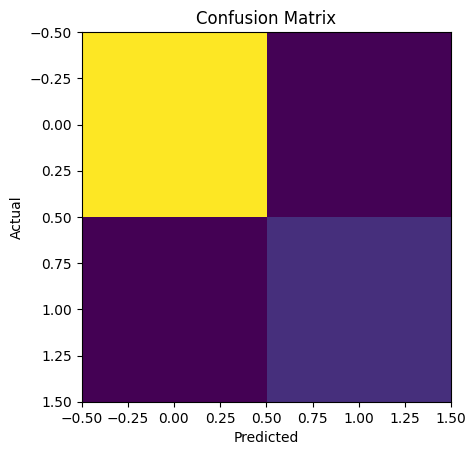

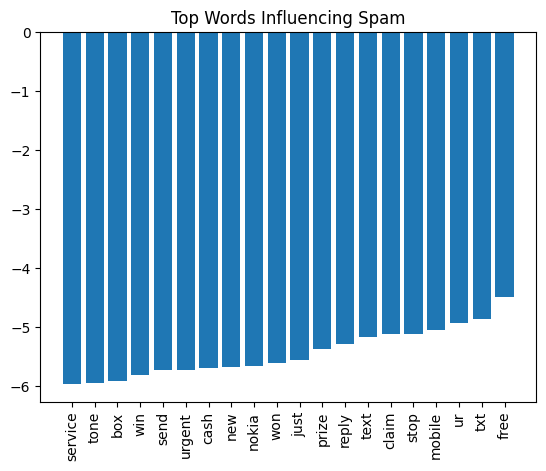

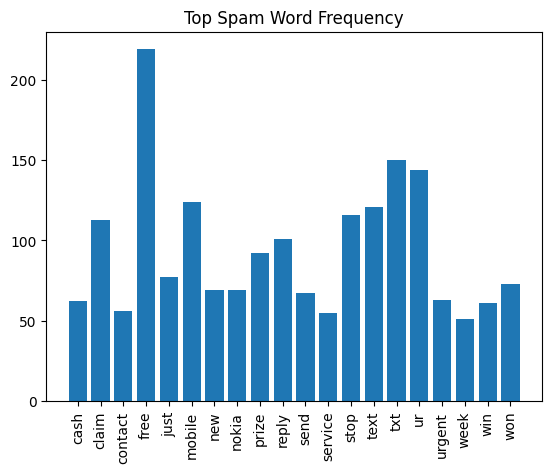

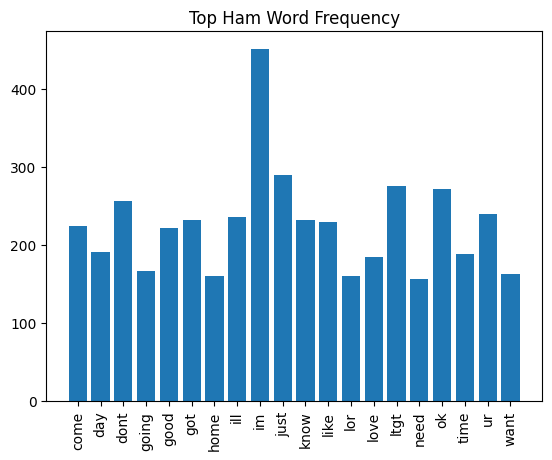

Accuracy with alpha=0.5: 0.9659192825112107


In [4]:
# ASWIN.S
# 24BAD014

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv('/content/spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

def clean_text(text_data):
    text_data = text_data.lower()
    text_data = re.sub(f"[{string.punctuation}]", "", text_data)
    text_data = re.sub(r"\d+", "", text_data)
    return text_data

df['clean_message'] = df['message'].apply(clean_text)

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['clean_message'])

df['label'] = df['label'].map({'ham': 0, 'spam': 1})
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

feature_names = np.array(vectorizer.get_feature_names_out())
spam_word_probs = model.feature_log_prob_[1]
top_spam_indices = np.argsort(spam_word_probs)[-20:]
top_spam_words = feature_names[top_spam_indices]

plt.figure()
plt.bar(top_spam_words, spam_word_probs[top_spam_indices])
plt.xticks(rotation=90)
plt.title("Top Words Influencing Spam")
plt.show()

spam_messages = df[df['label'] == 1]['clean_message']
spam_vector = CountVectorizer(stop_words='english', max_features=20)
spam_counts = spam_vector.fit_transform(spam_messages).sum(axis=0).A1

plt.figure()
plt.bar(spam_vector.get_feature_names_out(), spam_counts)
plt.xticks(rotation=90)
plt.title("Top Spam Word Frequency")
plt.show()

ham_messages = df[df['label'] == 0]['clean_message']
ham_vector = CountVectorizer(stop_words='english', max_features=20)
ham_counts = ham_vector.fit_transform(ham_messages).sum(axis=0).A1

plt.figure()
plt.bar(ham_vector.get_feature_names_out(), ham_counts)
plt.xticks(rotation=90)
plt.title("Top Ham Word Frequency")
plt.show()

model_smooth = MultinomialNB(alpha=0.5)
model_smooth.fit(X_train, y_train)
y_pred_smooth = model_smooth.predict(X_test)

print("Accuracy with alpha=0.5:", accuracy_score(y_test, y_pred_smooth))

Gaussian NB Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



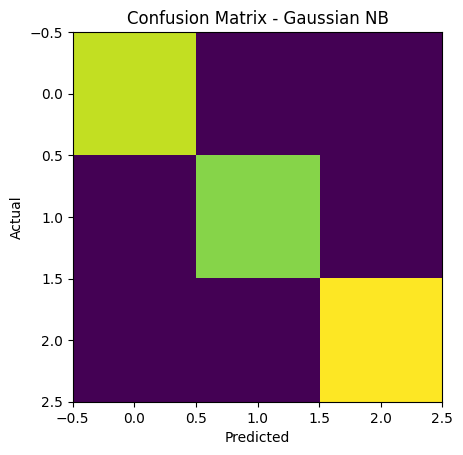


Predicted Probabilities (First 5 Samples):
 [[5.97322611e-090 9.95635768e-001 4.36423247e-003]
 [1.00000000e+000 4.96157683e-014 6.54921950e-021]
 [7.31861098e-290 4.92947289e-012 1.00000000e+000]
 [2.81838335e-094 9.77593560e-001 2.24064404e-002]
 [1.13876385e-105 8.70022604e-001 1.29977396e-001]]

Logistic Regression Accuracy: 1.0


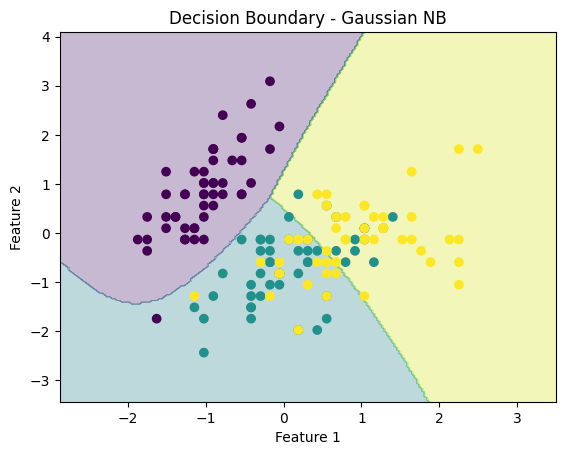

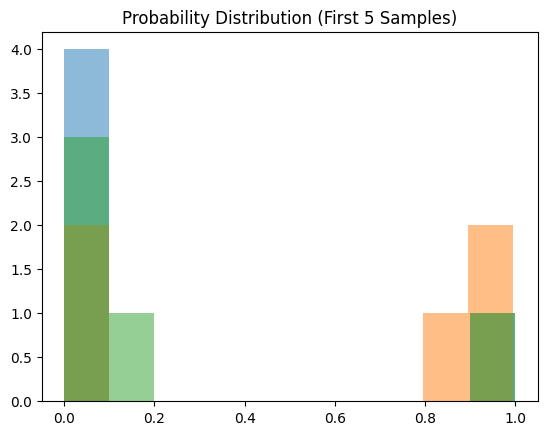

In [5]:
# ASWIN.S
# 24BAD014

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

print("Gaussian NB Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Gaussian NB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

probs = gnb.predict_proba(X_test[:5])
print("\nPredicted Probabilities (First 5 Samples):\n", probs)

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

X_two = X_scaled[:, :2]
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_two, y, test_size=0.2, random_state=42
)

gnb2 = GaussianNB()
gnb2.fit(X_train2, y_train2)

x_min, x_max = X_two[:, 0].min() - 1, X_two[:, 0].max() + 1
y_min, y_max = X_two[:, 1].min() - 1, X_two[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = gnb2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_two[:, 0], X_two[:, 1], c=y)
plt.title("Decision Boundary - Gaussian NB")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

plt.figure()
for i in range(3):
    plt.hist(probs[:, i], bins=10, alpha=0.5)
plt.title("Probability Distribution (First 5 Samples)")
plt.show()